# Playground to manually test a few architectures/hyperparameters
## Train LSTM pipeline and plot rolling forecasts for test profiles

In [1]:
from pathlib import Path

from rabl.machine_learning.lstm_pipeline import (
    LSTMPipeline,
    LSTMPipelineConfig,
    test_and_save_forecasts,
    clear_cuda_cache,
)

In [4]:
batch_size = 256
epochs = 50
seed = 123
max_plots = 5

n_lstm = 2
lstm_hidden = 256              # shared across stacked layers
lstm_dropout = 0.3            # ignored if n_lstm == 1 in nn.LSTM

n_fc = 1
fc_hidden = (128,)

learning_rate = 1e-3
preload_training_data = True


h5_path = Path("../outputs/datasets/lstm_merged_batches_0001-0002_k8_minmax_train0.70_val0.15_test0.15.h5")
out_dir = Path("../outputs/ml_results/training_playground/")
out_dir.mkdir(parents=True, exist_ok=True)

print("h5_path exists:", h5_path.exists())
print("out_dir:", out_dir)

h5_path exists: True
out_dir: ..\outputs\ml_results\training_playground


In [6]:
config = LSTMPipelineConfig(
    h5_path=h5_path,
    batch_size=batch_size,
    seed=seed,
    n_lstm=n_lstm,
    lstm_hidden=lstm_hidden,
    lstm_dropout=lstm_dropout,
    n_fc=n_fc,
    fc_hidden=tuple(fc_hidden),
    learning_rate=learning_rate,
)

pipeline = LSTMPipeline(config)

datasets = pipeline.build()
pipeline.inspect()

Dataset summary:
  H5 path:         ..\outputs\datasets\lstm_merged_batches_0001-0002_k8_minmax_train0.70_val0.15_test0.15.h5
  Batch size:      256
  Seed:            123

  Train profiles:  1400
  Val profiles:    300
  Test profiles:   300

  Sample X shape:  (2001, 9, 14)   (per-sample)
  Sample Y shape:  (2001, 13)   (per-sample)

  Train samples:   2,801,400  (~10,943 batches)
  Val samples:     600,300  (~2,345 batches)
  Test samples:    600,300  (profiles used for forecasting)

  loader cardinality (derived from precomputed counts):
    train:          10943
    val_samples:    2345
    val_profile_ds: 300
    test_profile_ds:300

Train batch X shape: torch.Size([256, 9, 14])
Train batch Y shape: torch.Size([256, 13])

Val profile: results_drum_profile_00006
  X profile shape: torch.Size([2001, 9, 14])
  Y profile shape: torch.Size([2001, 13])

Test profile: results_drum_profile_00004
  X profile shape: torch.Size([2001, 9, 14])
  Y profile shape: torch.Size([2001, 13])



Using GPU: NVIDIA GeForce RTX 4060 Ti

Deterministic seed set to: 123
LSTMRegressor architecture:
  Input features: 14
  LSTM layers (2): hidden_size=256, dropout=0.3
  FC layers (1): [128]
  Output targets: 13



Preloading train batches: 10943batch [00:21, 516.06batch/s]


Preloaded 10943 training batches to cuda:0 in 21.21s.


Train 1/50: 100%|█████████████████████████████████████████████| 10943/10943 [00:36<00:00, 301.34batch/s, loss=0.000118]
Val 1/50: 2345batch [00:06, 366.18batch/s]


Epoch 1/50 - loss: 0.000307 - val_loss: 0.000242 - data_wait: 0.16s - h2d: 0.00s - compute: 31.27s - val_time: 6.41s - preloaded: True - preload_time: 21.21s - max_cuda_mem: 1614.02 MB


...

Epoch 37/50 - loss: 0.000007 - val_loss: 0.000007 - data_wait: 0.16s - h2d: 0.00s - compute: 31.31s - val_time: 6.67s - preloaded: True - preload_time: 21.21s - max_cuda_mem: 1614.02 MB
Early stopping check: 8/10 epochs without validation improvement.


Train 38/50: 100%|████████████████████████████████████████████| 10943/10943 [00:35<00:00, 312.08batch/s, loss=0.000005]
Val 38/50: 2345batch [00:06, 357.36batch/s]


Epoch 38/50 - loss: 0.000007 - val_loss: 0.000007 - data_wait: 0.15s - h2d: 0.00s - compute: 30.08s - val_time: 6.56s - preloaded: True - preload_time: 21.21s - max_cuda_mem: 1614.02 MB
Early stopping check: 9/10 epochs without validation improvement.


Train 39/50: 100%|████████████████████████████████████████████| 10943/10943 [00:35<00:00, 305.55batch/s, loss=0.000006]
Val 39/50: 2345batch [00:06, 359.22batch/s]


Epoch 39/50 - loss: 0.000007 - val_loss: 0.000005 - data_wait: 0.15s - h2d: 0.00s - compute: 30.79s - val_time: 6.53s - preloaded: True - preload_time: 21.21s - max_cuda_mem: 1614.02 MB
Early stopping check: 10/10 epochs without validation improvement.
Early stopping triggered at epoch 39; best validation loss was 0.000005 at epoch 29.
Restored best model weights from epoch 29.
Saved training curves to ..\outputs\ml_results\training_playground\lstm_train_val_curve.png

Timing summary (cumulative):
  preload_time: 21.21s
  train_data_wait_time: 6.51s
  train_h2d_time: 0.05s
  train_compute_time: 1231.62s
  train_epoch_time_total: 1238.18s
  val_time_total: 258.16s
  estimated_total_time: 1517.55s
Finished training using device: cuda:0


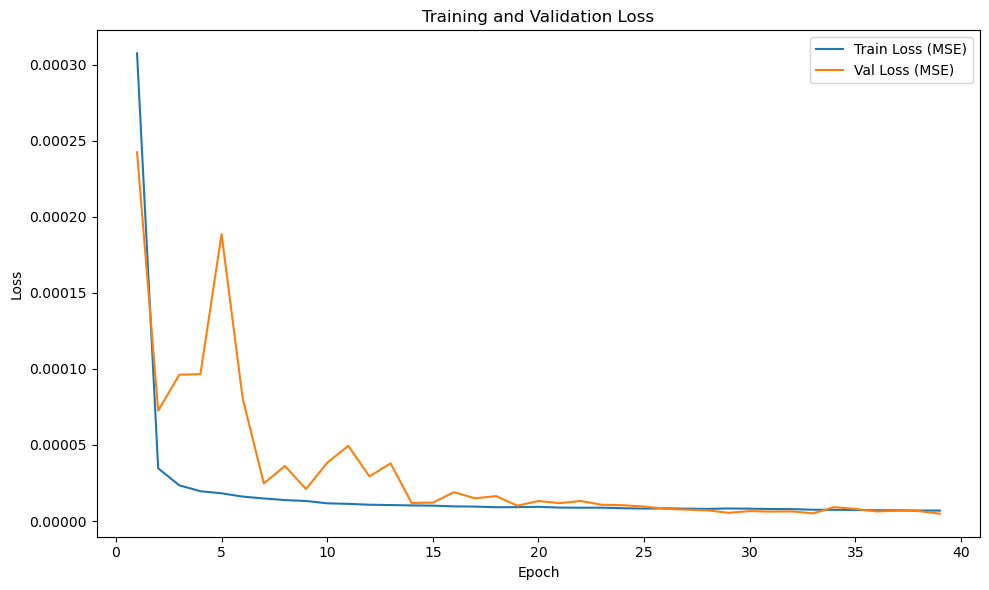

In [8]:
model, history, used_device = pipeline.train(
    epochs=epochs,
    out_dir=out_dir,
    preload_train_to_device=preload_training_data,
    early_stopping_min_delta=1e-6,
    early_stopping_patience=10,
    restore_best_weights=True
)
print(f"Finished training using device: {used_device}")

In [11]:
test_and_save_forecasts(
    model,
    datasets["test_profile_ds"],
    out_dir=out_dir,
    state_dim=pipeline.config.state_dim,
    control_channel=pipeline.config.control_channel,
    target_names=pipeline.config.target_names,
    max_plots=max_plots,
    plot_callback=pipeline.plot,
    h5_path=h5_path,
)

if "cuda" in str(used_device).lower():
    print(f"Clearing {used_device}...")
    del model
    clear_cuda_cache()

Forecast profiles: 1profile [00:02,  2.80s/profile, mse=1.004521e+09]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00004.png


Forecast profiles: 2profile [00:05,  2.73s/profile, mse=5.974725e+08]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00007.png


Forecast profiles: 3profile [00:08,  2.77s/profile, mse=6.165280e+08]

...

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00009.png


Forecast profiles: 5profile [00:13,  2.70s/profile, mse=9.254131e+08]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00016.png


Forecast profiles: 126profile [02:51,  1.36s/profile, mse=9.832370e+08]


KeyboardInterrupt: 